##### Script to compute monthly EOF1 patterns using geopotential height anomalies

##### 1. to compute monthly EOF based on weighted GH anomalies

In [1]:
import numpy as np
import xarray as xr

from eofs.xarray import Eof

In [6]:
import os
import glob
from pathlib import Path

- eof analysis for each year

In [47]:
def eof_analysis_eof1(
    pwtanom: xr.DataArray,
    *,
    lv: int,
    mon: int,
    neofs: int = 2,
    lat_name: str | None = None,
    lon_name: str | None = None,
    sign_lat: float = -60.0,
    sign_lon: float = 90.0,
    out_dir: str | Path = ".",
    save: bool = True,
    overwrite: bool = False,     # NEW: optional overwrite control
):
    """
    EOF analysis on weighted anomalies (pwtanom):
      - EOFs over (lat, lon), PCs over time (unit variance)
      - sign convention: ensure EOF1(lat≈-60, lon≈90E) > 0
      - regression pattern = <pwtanom * PC1_std> over time
      - saves EOF1 to ERA5.EOF1.z{lv}.Mon{mm}.nc if save=True

    Parameters
    ----------
    pwtanom : xr.DataArray
        Weighted anomalies with dims (time, lat, lon). Already demeaned across years for a month.
    lv, mon : int
        Pressure level (for filename) and calendar month.
    neofs : int
        Number of EOF modes to compute (default 2).
    lat_name, lon_name : str or None
        Coordinate names; auto-detected if None.
    sign_lat, sign_lon : float
        Reference point for sign convention (nearest grid point is used).
    out_dir : path-like
        Directory to save output NetCDF.
    save : bool
        Whether to write EOF1 to file.
    overwrite : bool
        Whether to overwrite an existing file (default False).

    Returns
    -------
    eof1 : xr.DataArray       (lat, lon)
    pc1_std : xr.DataArray    (time,)
    varfrac1 : float          variance fraction of EOF1 (0..1)
    """
    # --- coord names ---
    if lat_name is None:
        lat_name = "lat" if "lat" in pwtanom.dims else "latitude"
    if lon_name is None:
        lon_name = "lon" if "lon" in pwtanom.dims else "longitude"

    # ensure correct order (time, lat, lon)
    da = pwtanom.transpose("time", lat_name, lon_name)

    # --- output path ---
    out_dir = Path(out_dir)
    zeof_dir = out_dir / "zeof"
    zeof_dir.mkdir(parents=True, exist_ok=True)
    lv_label = int(lv / 100)  # hPa
    out_path = zeof_dir / f"ERA5.EOF1.z{lv_label}.Mon{mon:02d}.nc"

    # --- if file exists ---
    if save and out_path.exists() and not overwrite:
        print(f"Existing EOF1 file found: {out_path}")
        eof1 = xr.open_dataarray(out_path)
        return eof1

    # --- compute EOFs ---
    solver = Eof(da, center=False)
    eofs = solver.eofs(neofs=neofs, eofscaling=0)
    pcs = solver.pcs(npcs=neofs, pcscaling=1)
    varf = solver.varianceFraction()

    print(f"Explained variance: {varf.values[:neofs]}")

    eof1 = eofs.isel(mode=0)
    pc1_std = pcs.isel(mode=0)
    varfrac1 = float(varf.isel(mode=0).values)

    # --- sign convention ---
    lat_vals = eof1[lat_name].values
    lon_vals = eof1[lon_name].values
    ilat = int(np.argmin(np.abs(lat_vals - sign_lat)))
    lon360 = (lon_vals % 360 + 360) % 360
    sign_lon360 = sign_lon % 360
    ilon = int(np.argmin(np.abs(lon360 - sign_lon360)))

    flip = -1.0 if float(eof1.values[ilat, ilon]) < 0 else 1.0
    eof1 *= flip
    pc1_std *= flip

    # --- save to file ---
    if save:
        eof1.rename("eof1").to_dataset().to_netcdf(out_path)
        print(f"Saved EOF1 to {out_path}")

    return eof1


In [53]:
def compute_monthly_eof_series(
    da: xr.DataArray,
    *,
    lv: int,
    mons: list[int] | np.ndarray = range(1, 13),
    lat_min: float = -90,
    lat_max: float = -20,
    out_dir: str | Path = "./processed",
    save: bool = True,
    overwrite: bool = False,
):
    """
    Compute monthly EOF1 patterns from a multi-year geopotential height file.

    For each month:
      - Selects the corresponding subset from the full dataset
      - Sorts latitudes (ascending)
      - Applies √cos(lat) weighting
      - Computes anomalies across years
      - Runs EOF1 analysis via `eof_analysis_eof1`

    Parameters
    ----------
    da : xr.DataArray
        Multi-year geopotential height (time, lat, lon) [m].
    lv : int
        Pressure level in Pa (used for file naming).
    mons : list[int] or np.ndarray, optional
        List of months (1–12) to process.
    lat_min, lat_max : float, optional
        Latitude range to select (default: -90 to -20 for SH).
    out_dir : str or Path, optional
        Directory for output NetCDFs.
    save : bool, optional
        Whether to save EOF1 NetCDF files.
    overwrite : bool, optional
        Whether to overwrite existing files.

    Returns
    -------
    dict[int, xr.DataArray]
        Dictionary of EOF1 patterns for each processed month.
    """

    results = {}
    out_dir = Path(out_dir)

    # --- Sort latitude if needed ---
    if not np.all(np.diff(da["lat"]) > 0):
        da = da.sortby("lat")

    # --- Restrict latitude range ---
    da = da.sel(lat=slice(lat_min, lat_max))

    # --- Loop over requested months ---
    for mon in mons:
        print(f"\n Processing month: {mon:02d}")

        # Subset by month
        da_mon = da.sel(time=da.time.dt.month == mon)
        if da_mon.time.size == 0:
            print(f" No data for month {mon:02d}; skipping.")
            continue

        # Compute yearly mean for this month
        da_m = da_mon.groupby("time.year").mean("time")

        # Apply √cos(lat) weighting
        w = np.sqrt(np.cos(np.deg2rad(da_m["lat"])))
        da_weighted = da_m * w

        # Compute anomalies across years
        clim = da_weighted.mean("year")
        anom = (da_weighted - clim).rename(year="time").astype("float32")

        # Run EOF analysis
        eof1 = eof_analysis_eof1(
            anom,
            lv=lv,
            mon=mon,
            out_dir=out_dir,
            save=save,
            overwrite=overwrite,
        )

        results[mon] = eof1

    print("\n All requested months processed.")
    return results


- read in one single file with all years

In [59]:
gh_file = 'processed/era5_gh_10hPa_1979_2023.nc'
lv = 1000

In [60]:
gh_era5 = xr.open_dataset(gh_file)
gh_era5 = gh_era5['var129']

In [61]:
da = gh_era5

In [65]:
out_dir = './processed/'

In [66]:
mons = [6,7,8,9,10,11,12]

In [67]:
compute_monthly_eof_series(da, lv=lv, mons=mons)


 Processing month: 06
Explained variance: [0.46238026 0.18391357]
💾 Saved EOF1 to processed/zeof/ERA5.EOF1.z50.Mon06.nc

 Processing month: 07
Explained variance: [0.39484435 0.21443267]
💾 Saved EOF1 to processed/zeof/ERA5.EOF1.z50.Mon07.nc

 Processing month: 08
Explained variance: [0.55593485 0.20054151]
💾 Saved EOF1 to processed/zeof/ERA5.EOF1.z50.Mon08.nc

 Processing month: 09
Explained variance: [0.55601037 0.22196193]
💾 Saved EOF1 to processed/zeof/ERA5.EOF1.z50.Mon09.nc

 Processing month: 10
Explained variance: [0.56823677 0.2765826 ]
💾 Saved EOF1 to processed/zeof/ERA5.EOF1.z50.Mon10.nc

 Processing month: 11
Explained variance: [0.6866492  0.15531315]
💾 Saved EOF1 to processed/zeof/ERA5.EOF1.z50.Mon11.nc

 Processing month: 12
Explained variance: [0.6852531 0.1824325]
💾 Saved EOF1 to processed/zeof/ERA5.EOF1.z50.Mon12.nc

 All requested months processed.


{6: <xarray.DataArray 'eofs' (lat: 36, lon: 180)> Size: 26kB
 array([[ 6.6448333e-11,  6.6448493e-11,  6.6448486e-11, ...,
          6.6448312e-11,  6.6448312e-11,  6.6448312e-11],
        [ 1.8746021e-03,  1.8861073e-03,  1.8975830e-03, ...,
          1.8396330e-03,  1.8513252e-03,  1.8629533e-03],
        [ 2.6712304e-03,  2.7044180e-03,  2.7374611e-03, ...,
          2.5710242e-03,  2.6045004e-03,  2.6379034e-03],
        ...,
        [ 5.4481160e-04,  5.1293772e-04,  4.7921430e-04, ...,
          6.8777718e-04,  6.3582294e-04,  5.8807840e-04],
        [-6.8118487e-04, -7.1081519e-04, -7.4445916e-04, ...,
         -5.3777499e-04, -5.9331406e-04, -6.4166804e-04],
        [-1.5205175e-03, -1.5473550e-03, -1.5824701e-03, ...,
         -1.4002196e-03, -1.4486250e-03, -1.4892941e-03]], dtype=float32)
 Coordinates:
     mode     int64 8B 0
   * lat      (lat) float64 288B -90.0 -88.0 -86.0 -84.0 ... -24.0 -22.0 -20.0
   * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.

- plot to check the eof pattern

In [19]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

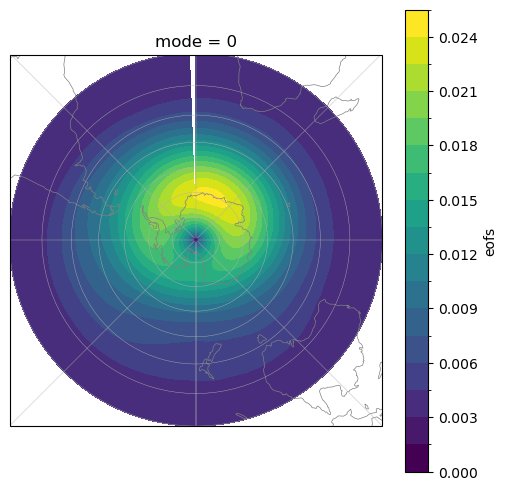

In [393]:
proj = ccrs.SouthPolarStereo()
fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, -90, -20], ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="gray")
ax.gridlines(draw_labels=False, xlocs=np.arange(-180, 181, 45),
             ylocs=np.arange(-90, -19, 10), linewidth=0.3)

# filled contours
h = eof_months[0].plot.contourf(ax=ax, transform=ccrs.PlateCarree(),
                     levels=21, add_colorbar=True)